In [ ]:
# ============================================================
# STOCK MARKET PRICE PREDICTION
# BiLSTM + GRU Hybrid Model | 10 Stocks | 10 Years of Data
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Input,
    Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import timedelta
import pickle
import os

# ── Google Drive folder containing all 10 CSV files ───────
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/data1010'

# ── Stock tickers and their CSV filenames ─────────────────
TICKERS = {
    'AAPL'  : 'AAPL_daily_10yr.csv',
    'AMZN'  : 'AMZN_daily_10yr.csv',
    'BAC'   : 'BAC_daily_10yr.csv',
    'BLK'   : 'BLK_daily_10yr.csv',
    'GOOGL' : 'GOOGL_daily_10yr.csv',
    'JPM'   : 'JPM_daily_10yr.csv',
    'META'  : 'META_daily_10yr.csv',
    'MSFT'  : 'MSFT_daily_10yr.csv',
    'NVDA'  : 'NVDA_daily_10yr.csv',
    'TSLA'  : 'TSLA_daily_10yr.csv',
}

# ── Feature columns the model trains on ───────────────────
FEATURE_COLS = [
    'Log_Returns',
    'RSI_14',
    'EMA_ratio',
    'Volume_ratio',
    'Volatility_20',
    'MACD_signal',
    'ATR_ratio',
    'Momentum_5',
    'Return_Direction',

    # NEW
    'Momentum_1',
    'Momentum_3',
    'Momentum_10',
    'RSI_change',
    'Trend_Strength',
    'Volatility_change',
    'EMA_distance',
    'Breakout',
    'Market_trend'
]
TARGET_COL = 'Target_Direction'
LOOKBACK    = 90    # days of history the model sees at once
TRAIN_RATIO = 0.8   # 80% training, 20% test

print("Setup complete.")
print(f"Drive path : {DRIVE_PATH}")
print(f"Stocks     : {list(TICKERS.keys())}")
print(f"Features   : {len(FEATURE_COLS)}")
print(f"Lookback   : {LOOKBACK} days")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.
Drive path : /content/drive/MyDrive/Colab Notebooks/data1010
Stocks     : ['AAPL', 'AMZN', 'BAC', 'BLK', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA']
Features   : 18
Lookback   : 90 days


In [ ]:
# ============================================================
# CELL 2 — FEATURE ENGINEERING
#
# Takes raw Yahoo Finance OHLCV columns and builds 10
# scale-independent features that work across all stocks.
#
# We use Adj Close (not Close) as the price base because
# it accounts for stock splits over 10 years of history.
# ============================================================

def build_features(df):
    # close  = df['Adj Close']
    # Use Adj Close if available, otherwise fallback to Close
    close = df['Adj Close'] if 'Adj Close' in df.columns else df['Close']
    high   = df['High']
    low    = df['Low']
    volume = df['Volume']

    out = pd.DataFrame(index=df.index)

    # 1. Close — the prediction target
    out['Close'] = close

    # 2. Log Returns — daily % change, scale-free across stocks
    out['Log_Returns'] = np.log(close / close.shift(1))

    # 3. RSI 14 — momentum, always 0–100
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    out['RSI_14'] = 100 - (100 / (1 + gain / loss))

    # 4. EMA ratio — trend direction without raw dollar values
    #    > 1.0 = short-term trend above medium-term (bullish)
    #    < 1.0 = short-term trend below medium-term (bearish)
    ema_9  = close.ewm(span=9,  adjust=False).mean()
    ema_20 = close.ewm(span=20, adjust=False).mean()
    out['EMA_ratio'] = ema_9 / ema_20

    # 5. Volume ratio — today vs own 20-day average
    #    2.0 = twice as busy as usual (same meaning any stock)
    out['Volume_ratio'] = volume / volume.rolling(20).mean()

    # 6. Volatility — 20-day rolling std of log returns
    #    tells the model how choppy this stock has been lately
    out['Volatility_20'] = out['Log_Returns'].rolling(20).std()

    # 7. MACD signal — momentum divergence, divided by price
    #    to make it scale-free across different price levels
    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    macd   = ema_12 - ema_26
    signal = macd.ewm(span=9, adjust=False).mean()
    out['MACD_signal'] = (macd - signal) / close

    # 8. ATR ratio — intraday range as % of price
    #    captures how much the stock typically swings each day
    prev_close = close.shift(1)
    true_range = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    out['ATR_ratio'] = true_range.rolling(14).mean() / close

    # 9. Momentum 5 — price vs 5 days ago as a %
    #    gives the model explicit short-term direction context
    out['Momentum_5'] = (close - close.shift(5)) / close.shift(5)

    # 10. Return Direction — was yesterday positive or negative
    #     simple +1/-1 flag that helps kill the lag problem
    out['Return_Direction'] = np.sign(out['Log_Returns'].shift(1))
    threshold = 0.002  # 0.2%

    # 9.5 Market trend — rolling mean direction over 5 days
    out['Market_trend'] = np.sign(out['Log_Returns'].rolling(5).mean())
    # 11. Future return — next day's return
    out['Future_Return'] = out['Close'].shift(-1) / out['Close'] - 1

# Ignore tiny/noisy moves
    threshold_move = 0.002   # 0.2%

    out['Target_Direction'] = np.where(
        out['Future_Return'] > threshold_move, 1,
        np.where(out['Future_Return'] < -threshold_move, 0, np.nan)
        )

    # 1. Short momentum
    out['Momentum_1'] = close.pct_change(1)

    # 2. 3-day momentum
    out['Momentum_3'] = close.pct_change(3)

    # 3. RSI slope (change in momentum)
    out['RSI_change'] = out['RSI_14'].diff()

    # 4. Volatility spike
    out['Volatility_change'] = out['Volatility_20'].diff()

    # 5. Price vs EMA distance
    out['EMA_distance'] = (close - ema_20) / close
    # Extra directional features
    out['Momentum_1'] = close.pct_change(1)
    out['Momentum_3'] = close.pct_change(3)
    out['Momentum_10'] = close.pct_change(10)

    out['RSI_change'] = out['RSI_14'].diff()
    out['Volatility_change'] = out['Volatility_20'].diff()

    out['EMA_distance'] = (close - ema_20) / close
    out['Trend_Strength'] = (ema_9 - ema_20) / close

    rolling_high = close.rolling(10).max()
    rolling_low = close.rolling(10).min()
    out['Breakout'] = (
        (close > rolling_high.shift(1)).astype(int)
        - (close < rolling_low.shift(1)).astype(int)
    )



    out.dropna(inplace=True)
    return out

print("Feature engineering function ready.")
print(f"Will produce {len(FEATURE_COLS)} features per trading day.")

Feature engineering function ready.
Will produce 18 features per trading day.


In [ ]:
print("Class balance:")
print(df['Target_Direction'].value_counts(normalize=True))

Class balance:
Target_Direction
1    0.516647
0    0.483353
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# CELL 3 — LOAD ALL 10 STOCKS & BUILD TRAINING DATA
#
# Classification version:
# - X = scaled feature sequences
# - y = next-day direction label (0 = down, 1 = up)
# ============================================================

def prepare_single_stock(file_path, lookback=LOOKBACK):
    df = pd.read_csv(file_path, index_col=0)
    df.index = pd.to_datetime(df.index)

    # Build features + classification target
    df = build_features(df)

    # X uses only feature columns
    data = df[FEATURE_COLS].values

    # y uses direction target directly (0/1)
    targets = df[TARGET_COL].values

    # Step 1 — split BEFORE scaling
    split = int(len(data) * TRAIN_RATIO)

    train_raw = data[:split]
    test_raw = data[split:]

    y_train_raw = targets[:split]
    y_test_raw = targets[split:]

    # Step 2 — fit scaler on training features only
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)
    test_scaled = scaler.transform(test_raw)

    full_scaled = np.vstack((train_scaled, test_scaled))
    full_targets = np.concatenate((y_train_raw, y_test_raw))

    # Step 3 — build sliding windows
    # Each X = lookback days × feature count
    # Each y = next day's direction (0 or 1)
    X, y = [], []
    for i in range(lookback, len(full_scaled)):
        X.append(full_scaled[i - lookback:i])
        y.append(full_targets[i])

    X = np.array(X)
    y = np.array(y).astype(np.float32)

    # Step 4 — keep stock split intact
    train_samples = split - lookback

    return (
        X[:train_samples], X[train_samples:],
        y[:train_samples], y[train_samples:],
        scaler, df
    )


# ── Load all 10 stocks ────────────────────────────────────
all_X_train, all_X_test = [], []
all_y_train, all_y_test = [], []
scalers = {}
dfs = {}

print("Loading and processing stocks...\n")

for ticker, filename in TICKERS.items():
    file_path = os.path.join(DRIVE_PATH, filename)

    if not os.path.exists(file_path):
        print(f"  SKIPPED {ticker} — file not found at {file_path}")
        continue

    X_tr, X_te, y_tr, y_te, scaler, df = prepare_single_stock(file_path)

    all_X_train.append(X_tr)
    all_X_test.append(X_te)
    all_y_train.append(y_tr)
    all_y_test.append(y_te)
    scalers[ticker] = scaler
    dfs[ticker] = df

    print(f"  {ticker:6s}  rows: {len(df):5d}  train: {len(X_tr):4d}  test: {len(X_te):4d}")

# Combine all stocks
X_train = np.concatenate(all_X_train, axis=0)
X_test_all = np.concatenate(all_X_test, axis=0)
y_train = np.concatenate(all_y_train, axis=0)
y_test_all = np.concatenate(all_y_test, axis=0)

# Shuffle ONLY the training data
idx = np.random.permutation(len(X_train))
X_train, y_train = X_train[idx], y_train[idx]

# Split the old test set into validation + final test
val_split = int(len(X_test_all) * 0.5)

X_val = X_test_all[:val_split]
y_val = y_test_all[:val_split]

X_test = X_test_all[val_split:]
y_test = y_test_all[val_split:]

print(f"\nStocks loaded          : {list(scalers.keys())}")
print(f"Combined train shape   : {X_train.shape}")
print(f"Combined val shape     : {X_val.shape}")
print(f"Combined test shape    : {X_test.shape}")
print(f"  → {X_train.shape[0]} training sequences")
print(f"  → {X_train.shape[1]} days lookback")
print(f"  → {X_train.shape[2]} features per day")

Loading and processing stocks...

  AAPL    rows:  2156  train: 1634  test:  432
  AMZN    rows:  2201  train: 1670  test:  441
  BAC     rows:  2198  train: 1668  test:  440
  BLK     rows:  2139  train: 1621  test:  428
  GOOGL   rows:  2169  train: 1645  test:  434
  JPM     rows:  2122  train: 1607  test:  425
  META    rows:  2212  train: 1679  test:  443
  MSFT    rows:  2096  train: 1586  test:  420
  NVDA    rows:  2330  train: 1774  test:  466
  TSLA    rows:  2318  train: 1764  test:  464

Stocks loaded          : ['AAPL', 'AMZN', 'BAC', 'BLK', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA']
Combined train shape   : (16648, 90, 18)
Combined val shape     : (2196, 90, 18)
Combined test shape    : (2197, 90, 18)
  → 16648 training sequences
  → 90 days lookback
  → 18 features per day


In [ ]:
# ============================================================
# CELL 4 — MODEL ARCHITECTURE
#
# BiLSTM (128 units)
#   Reads the 60-day window forwards AND backwards.
#   Gives the model both historical trend context and
#   recent pattern awareness at the same time.
#   L2 regularisation prevents memorising training stocks.
#
# GRU layer 1 (64 units)
#   Lighter than LSTM, better at catching short-term
#   sharp movements. Extracts medium-term patterns.
#
# GRU layer 2 (32 units)
#   Sharpens the representation into a compact summary
#   before the dense layers make the final prediction.
#
# Dense layers
#   Two layers gradually compress to a single output:
#   the predicted next-day Close price (scaled 0–1).
# ============================================================

def build_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        # BiLSTM
        Bidirectional(LSTM(
            units=32,
            return_sequences=True,
            kernel_regularizer=l2(1e-4)
        )),
        BatchNormalization(),
        Dropout(0.2),

        # GRU
        GRU(
            units=32,
            return_sequences=False,
            kernel_regularizer=l2(1e-4)
        ),
        Dropout(0.2),

        # Dense layers
        Dense(32, activation='relu'),

        # Output: probability of UP move
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.summary()
    return model


model = build_model((X_train.shape[1], X_train.shape[2]))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 90, 64)         │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 90, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,809 (93.00 KB)

 Trainable params: 23,681 (92.50 KB)

 Non-trainable params: 128 (512.00 B)

Class weights: {np.float32(0.0): np.float64(1.0735104462213052), np.float32(1.0): np.float64(0.9359118506858556)}
Epoch 1/25
521/521 ━━━━━━━━━━━━━━━━━━━━ 42s 74ms/step - accuracy: 0.5044 - loss: 0.7155 - val_accuracy: 0.5364 - val_loss: 0.7046 - learning_rate: 1.0000e-04
Epoch 2/25
521/521 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.5019 - loss: 0.7102 - val_accuracy: 0.4964 - val_loss: 0.7065 - learning_rate: 2.0000e-04
Epoch 3/25
521/521 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.4990 - loss: 0.7077 - val_accuracy: 0.5319 - val_loss: 0.7032 - learning_rate: 3.0000e-04
Epoch 4/25
521/521 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - accuracy: 0.5051 - loss: 0.7060 - val_accuracy: 0.5305 - val_loss: 0.7017 - learning_rate: 4.0000e-04
Epoch 5/25
521/521 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step - accuracy: 0.5039 - loss: 0.7046 - val_accuracy: 0.4991 - val_loss: 0.7040 - learning_rate: 4.0000e-04
Epoch 6/25
521/521 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.5037 - loss: 0.7030 - val_ac

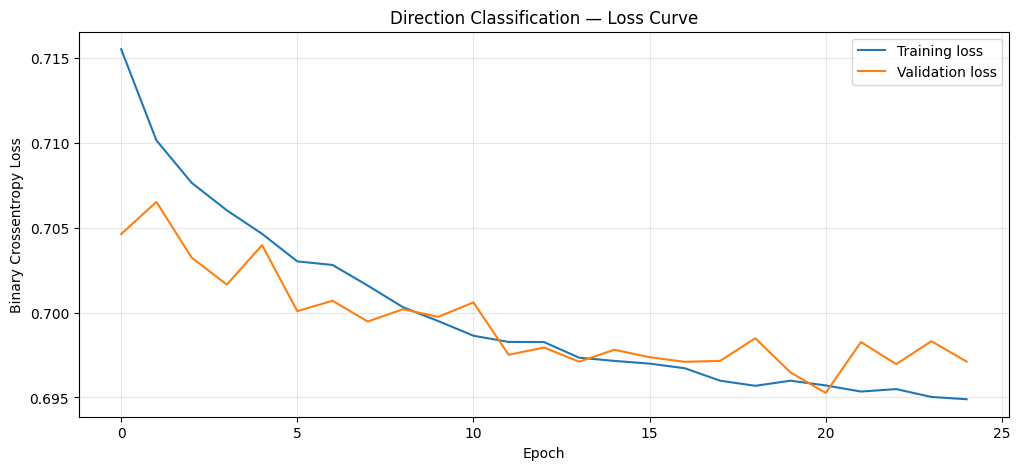

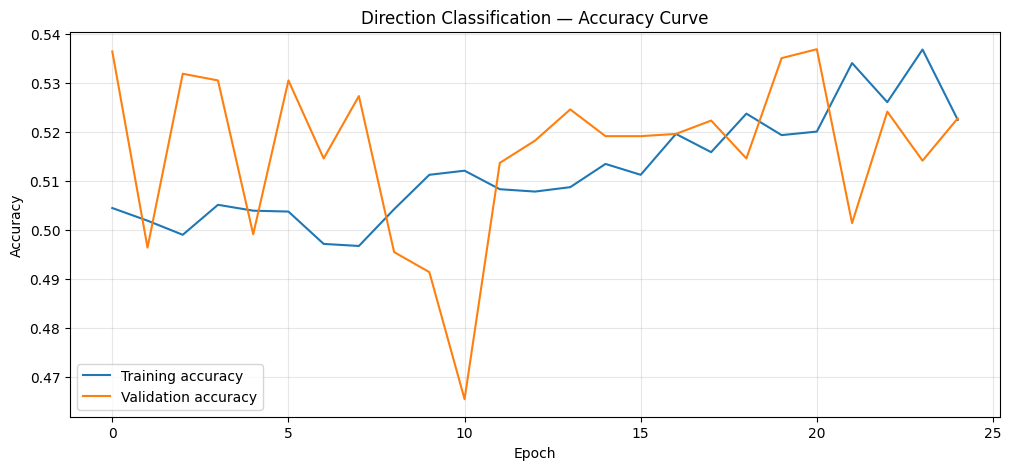

In [ ]:
# ============================================================
# CELL 5 — TRAINING
#
# Learning rate warmup:
#   Starts low (0.0001) and ramps to 0.001 over 5 epochs.
#   Prevents bad early weight updates that the model
#   never fully recovers from.
#
# EarlyStopping:
#   Monitors validation loss. Stops training when it stops
#   improving and restores the best weights automatically.
#   Prevents overfitting without guessing the epoch count.
#
# ReduceLROnPlateau:
#   Halves the learning rate when training stalls.
#   Lets the model make large updates early and fine-tune
#   carefully as it converges.
# ============================================================

def lr_warmup_schedule(epoch, lr):
    warmup_epochs = 4
    initial_lr = 0.0001
    target_lr = 0.0005

    if epoch < warmup_epochs:
        return initial_lr + (target_lr - initial_lr) * (epoch / warmup_epochs)
    return lr

lr_warmup = tf.keras.callbacks.LearningRateScheduler(
    lr_warmup_schedule, verbose=0
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train.astype(int)
)

class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=25,
    validation_data=(X_val, y_val),
    callbacks=[lr_warmup, reduce_lr, early_stop],
    class_weight=class_weights,
    shuffle=True,
    verbose=1
)
# Loss curve
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Direction Classification — Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Accuracy curve
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Direction Classification — Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# SAVE DIRECTION MODEL + SCALERS
# ============================================================

import os
import joblib

MODEL_PATH = "/content/drive/MyDrive/StockModels/"
os.makedirs(MODEL_PATH, exist_ok=True)

# Save model (NEW Keras format)
model.save(os.path.join(MODEL_PATH, "direction_model.keras"))

# Save all scalers (one dict)
joblib.dump(scalers, os.path.join(MODEL_PATH, "direction_scalers.pkl"))

print("✅ Direction model + scalers saved!")

✅ Direction model + scalers saved!


In [ ]:
# ============================================================
# CELL 6 — EVALUATION (CLASSIFICATION)
#
# Reports:
#   Accuracy (%)      — overall direction accuracy
#   Precision (%)     — how often predicted UP was correct
#   Recall (%)        — how many real UP moves were found
#   Predicted UP (%)  — how often the model predicts UP
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def evaluate_all_stocks(model, scalers, dfs, threshold=0.5):
    results = {}

    print("=" * 55)
    print("  PER-STOCK DIRECTION CLASSIFICATION REPORT")
    print("=" * 55)

    for ticker, scaler in scalers.items():
        fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

        # Rebuild this stock's test sequences
        _, X_te, _, y_te, _, _ = prepare_single_stock(fpath)

        # Predict probabilities
        y_pred_prob = model.predict(X_te, verbose=0).flatten()

        # Convert probabilities to class labels
        y_pred = (y_pred_prob >= threshold).astype(int)
        y_true = y_te.astype(int)

        acc = accuracy_score(y_true, y_pred) * 100
        precision = precision_score(y_true, y_pred, zero_division=0) * 100
        recall = recall_score(y_true, y_pred, zero_division=0) * 100
        up_rate = np.mean(y_pred) * 100

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        results[ticker] = {
            'Accuracy (%)': round(acc, 2),
            'Precision (%)': round(precision, 2),
            'Recall (%)': round(recall, 2),
            'Predicted UP (%)': round(up_rate, 2),
        }

        print(f"\n  {ticker}")
        print(f"    Accuracy        : {acc:.2f}%")
        print(f"    Precision       : {precision:.2f}%")
        print(f"    Recall          : {recall:.2f}%")
        print(f"    Predicted UP    : {up_rate:.2f}%")
        print(f"    TP={tp}  FP={fp}  TN={tn}  FN={fn}")

    df_results = pd.DataFrame(results).T.sort_values('Accuracy (%)', ascending=False)

    print("\n" + "=" * 55)
    print("  SUMMARY — RANKED BY ACCURACY")
    print("=" * 55)
    print(df_results.to_string())

    print(f"\n  Average Accuracy  : {df_results['Accuracy (%)'].mean():.2f}%")
    print(f"  Average Precision : {df_results['Precision (%)'].mean():.2f}%")
    print(f"  Average Recall    : {df_results['Recall (%)'].mean():.2f}%")

    return df_results

print("threshold=0.52")
results_df_052 = evaluate_all_stocks(model, scalers, dfs, threshold=0.52)

# print("threshold=0.53")
# results_df_053 = evaluate_all_stocks(model, scalers, dfs, threshold=0.53)

# print("threshold=0.54")
# results_df_054 = evaluate_all_stocks(model, scalers, dfs, threshold=0.54)



threshold=0.52
  PER-STOCK DIRECTION CLASSIFICATION REPORT

  AAPL
    Accuracy        : 47.69%
    Precision       : 53.36%
    Recall          : 49.38%
    Predicted UP    : 51.62%
    TP=119  FP=104  TN=87  FN=122

  AMZN
    Accuracy        : 50.34%
    Precision       : 54.08%
    Recall          : 23.35%
    Predicted UP    : 22.22%
    TP=53  FP=45  TN=169  FN=174

  BAC
    Accuracy        : 48.41%
    Precision       : 53.90%
    Recall          : 31.93%
    Predicted UP    : 32.05%
    TP=76  FP=65  TN=137  FN=162

  BLK
    Accuracy        : 52.10%
    Precision       : 53.13%
    Recall          : 78.76%
    Predicted UP    : 78.27%
    TP=178  FP=157  TN=45  FN=48

  GOOGL
    Accuracy        : 46.31%
    Precision       : 56.25%
    Recall          : 22.04%
    Predicted UP    : 22.12%
    TP=54  FP=42  TN=147  FN=191

  JPM
    Accuracy        : 46.35%
    Precision       : 62.86%
    Recall          : 17.89%
    Predicted UP    : 16.47%
    TP=44  FP=26  TN=153  FN=202


In [ ]:
import seaborn as sns

def plot_confusion(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

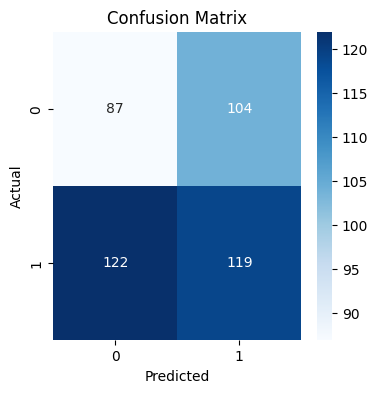

In [ ]:
# ============================================================
# CONFUSION MATRIX — EXAMPLE (AAPL)
# ============================================================

ticker = 'AAPL'

# Rebuild test data
fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])
_, X_te, _, y_te, _, _ = prepare_single_stock(fpath)

# Predict probabilities
y_pred_prob = model.predict(X_te, verbose=0).flatten()

# Use your best threshold
threshold = 0.52

# Convert to classes
y_pred = (y_pred_prob >= threshold).astype(int)
y_true = y_te.astype(int)

# Plot confusion matrix
plot_confusion(y_true, y_pred)

In [ ]:
# ============================================================
# BASELINE — ALWAYS PREDICT UP
# ============================================================

def baseline_accuracy():
    accs = []

    print("=" * 55)
    print("  BASELINE — ALWAYS PREDICT UP")
    print("=" * 55)

    for ticker in TICKERS.keys():
        fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

        if not os.path.exists(fpath):
            print(f"{ticker}: file not found")
            continue

        # Get this stock's test labels from your existing pipeline
        _, X_te, _, y_te, _, _ = prepare_single_stock(fpath)

        y_true = y_te.astype(int)

        # Baseline: always predict UP
        y_pred = np.ones_like(y_true)

        acc = np.mean(y_true == y_pred) * 100
        accs.append(acc)

        print(f"{ticker}: {acc:.2f}%")

    print(f"\nBaseline Average Accuracy: {np.mean(accs):.2f}%")

baseline_accuracy()

  BASELINE — ALWAYS PREDICT UP
AAPL: 55.79%
AMZN: 51.47%
BAC: 54.09%
BLK: 52.80%
GOOGL: 56.45%
JPM: 57.88%
META: 51.92%
MSFT: 53.57%
NVDA: 55.15%
TSLA: 50.22%

Baseline Average Accuracy: 53.93%


In [ ]:
# ============================================================
# CELL 8 — NEXT-DAY PREDICTION
#
# Change PREDICT_TICKER to any of the 10 loaded stocks.
# Available: AAPL  AMZN  BAC  BLK  GOOGL
#            JPM   META  MSFT NVDA  TSLA
# ============================================================

PREDICT_TICKER = 'AAPL'

def predict_next_day(ticker, model, scalers, dfs):
    if ticker not in scalers:
        print(f"'{ticker}' not found.")
        print(f"Available: {list(scalers.keys())}")
        return

    scaler    = scalers[ticker]
    file_path = os.path.join(DRIVE_PATH, TICKERS[ticker])

    df_raw = pd.read_csv(file_path, index_col=0)
    df_raw.index = pd.to_datetime(df_raw.index)
    df_feat = build_features(df_raw)

    # Take the last 60 days, scale, and reshape for the model
    recent = df_feat[FEATURE_COLS].tail(LOOKBACK).values
    scaled = scaler.transform(recent).reshape(
        1, LOOKBACK, len(FEATURE_COLS)
    )

    # Predict scaled Close, inverse-transform to dollars
    pred_scaled = model.predict(scaled, verbose=0)[0, 0]
    dummy       = np.zeros((1, scaler.n_features_in_))
    dummy[0, 0] = pred_scaled
    next_price  = scaler.inverse_transform(dummy)[0, 0]

    last_close = df_feat['Close'].iloc[-1]
    last_date  = df_feat.index[-1]
    change     = next_price - last_close
    direction  = "UP" if change > 0 else "DOWN"

    # Find next trading day (skip weekends)
    next_date = last_date + timedelta(days=1)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    print("=" * 46)
    print(f"  NEXT-DAY PREDICTION — {ticker}")
    print("=" * 46)
    print(f"  Data up to  :  {last_date.strftime('%Y-%m-%d')}")
    print(f"  Predicting  :  {next_date.strftime('%Y-%m-%d')}")
    print(f"  Last close  :  ${last_close:.2f}")
    print(f"  Predicted   :  ${next_price:.2f}")
    print(f"  Direction   :  {direction}  ${abs(change):.2f}")
    print("=" * 46)
    return next_price


predict_next_day(PREDICT_TICKER, model, scalers, dfs)

  NEXT-DAY PREDICTION — AAPL
  Data up to  :  2026-03-12
  Predicting  :  2026-03-13
  Last close  :  $255.76
  Predicted   :  $-0.01
  Direction   :  DOWN  $255.77


np.float64(-0.00657439006393109)

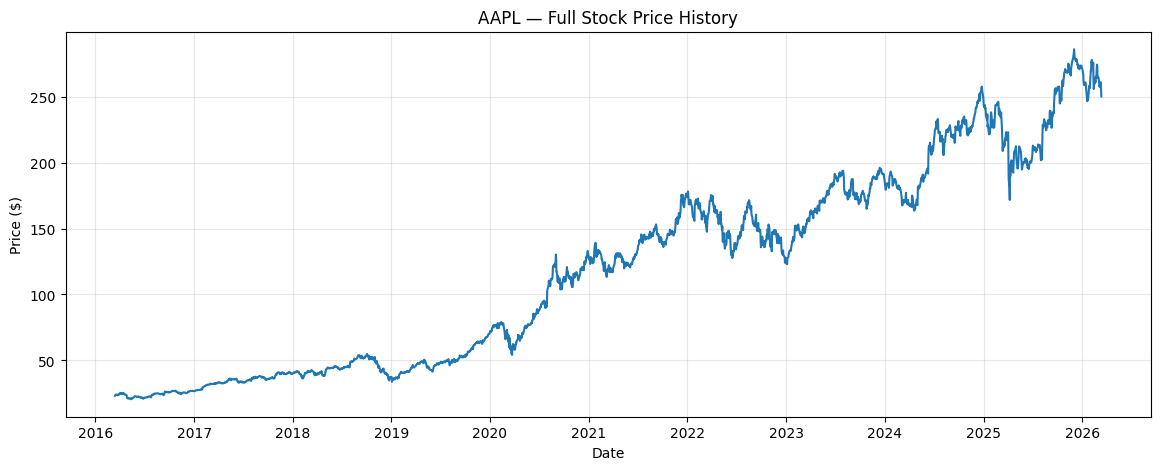

In [ ]:
# ============================================================
# STOCK PRICE CHART — FULL HISTORY
# ============================================================

ticker = 'AAPL'
file_path = os.path.join(DRIVE_PATH, TICKERS[ticker])

df_raw = pd.read_csv(file_path, index_col=0)
df_raw.index = pd.to_datetime(df_raw.index)

# Use Adj Close if available, else Close
close_col = 'Adj Close' if 'Adj Close' in df_raw.columns else 'Close'

plt.figure(figsize=(14, 5))
plt.plot(df_raw.index, df_raw[close_col], linewidth=1.5)
plt.title(f'{ticker} — Full Stock Price History')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.show()

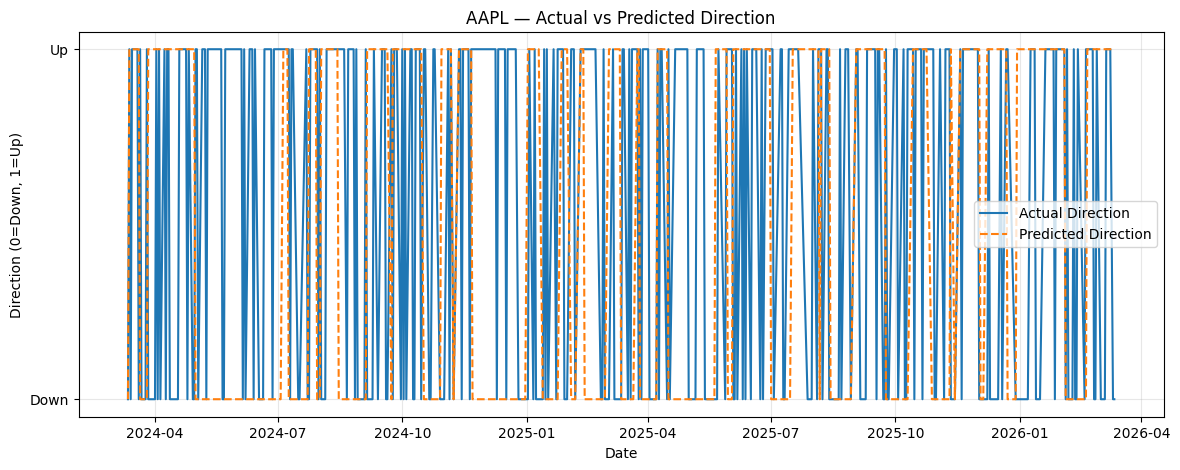

In [ ]:
# ============================================================
# ACTUAL VS PREDICTED DIRECTION — TEST SET
# ============================================================

ticker = 'AAPL'
threshold = 0.52

fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])
df_raw = pd.read_csv(fpath, index_col=0)
df_raw.index = pd.to_datetime(df_raw.index)

# rebuild stock test set
_, X_te, _, y_te, _, df_feat = prepare_single_stock(fpath)

y_pred_prob = model.predict(X_te, verbose=0).flatten()
y_pred = (y_pred_prob >= threshold).astype(int)
y_true = y_te.astype(int)

# Build dates aligned to test set
test_dates = df_feat.index[-len(y_true):]

plot_df = pd.DataFrame({
    'Date': test_dates,
    'Actual_Direction': y_true,
    'Predicted_Direction': y_pred
})

plt.figure(figsize=(14, 5))
plt.plot(plot_df['Date'], plot_df['Actual_Direction'], label='Actual Direction', linewidth=1.5)
plt.plot(plot_df['Date'], plot_df['Predicted_Direction'], label='Predicted Direction', linestyle='--', linewidth=1.5)
plt.title(f'{ticker} — Actual vs Predicted Direction')
plt.xlabel('Date')
plt.ylabel('Direction (0=Down, 1=Up)')
plt.yticks([0, 1], ['Down', 'Up'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

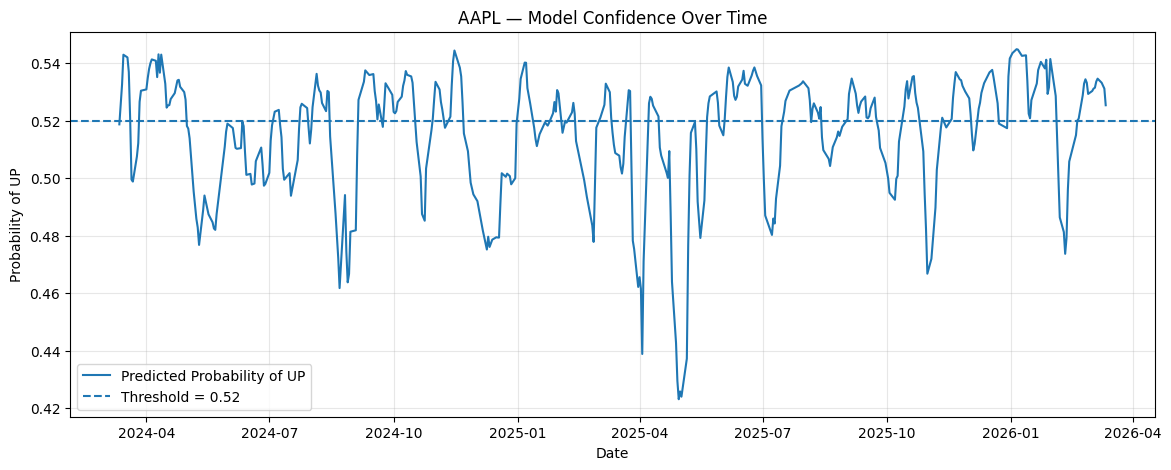

In [ ]:
# ============================================================
# MODEL CONFIDENCE — PROBABILITY OF UP
# ============================================================

ticker = 'AAPL'
threshold = 0.52

fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])
_, X_te, _, y_te, _, df_feat = prepare_single_stock(fpath)

y_pred_prob = model.predict(X_te, verbose=0).flatten()
test_dates = df_feat.index[-len(y_pred_prob):]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_pred_prob, label='Predicted Probability of UP', linewidth=1.5)
plt.axhline(threshold, linestyle='--', label=f'Threshold = {threshold}')
plt.title(f'{ticker} — Model Confidence Over Time')
plt.xlabel('Date')
plt.ylabel('Probability of UP')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

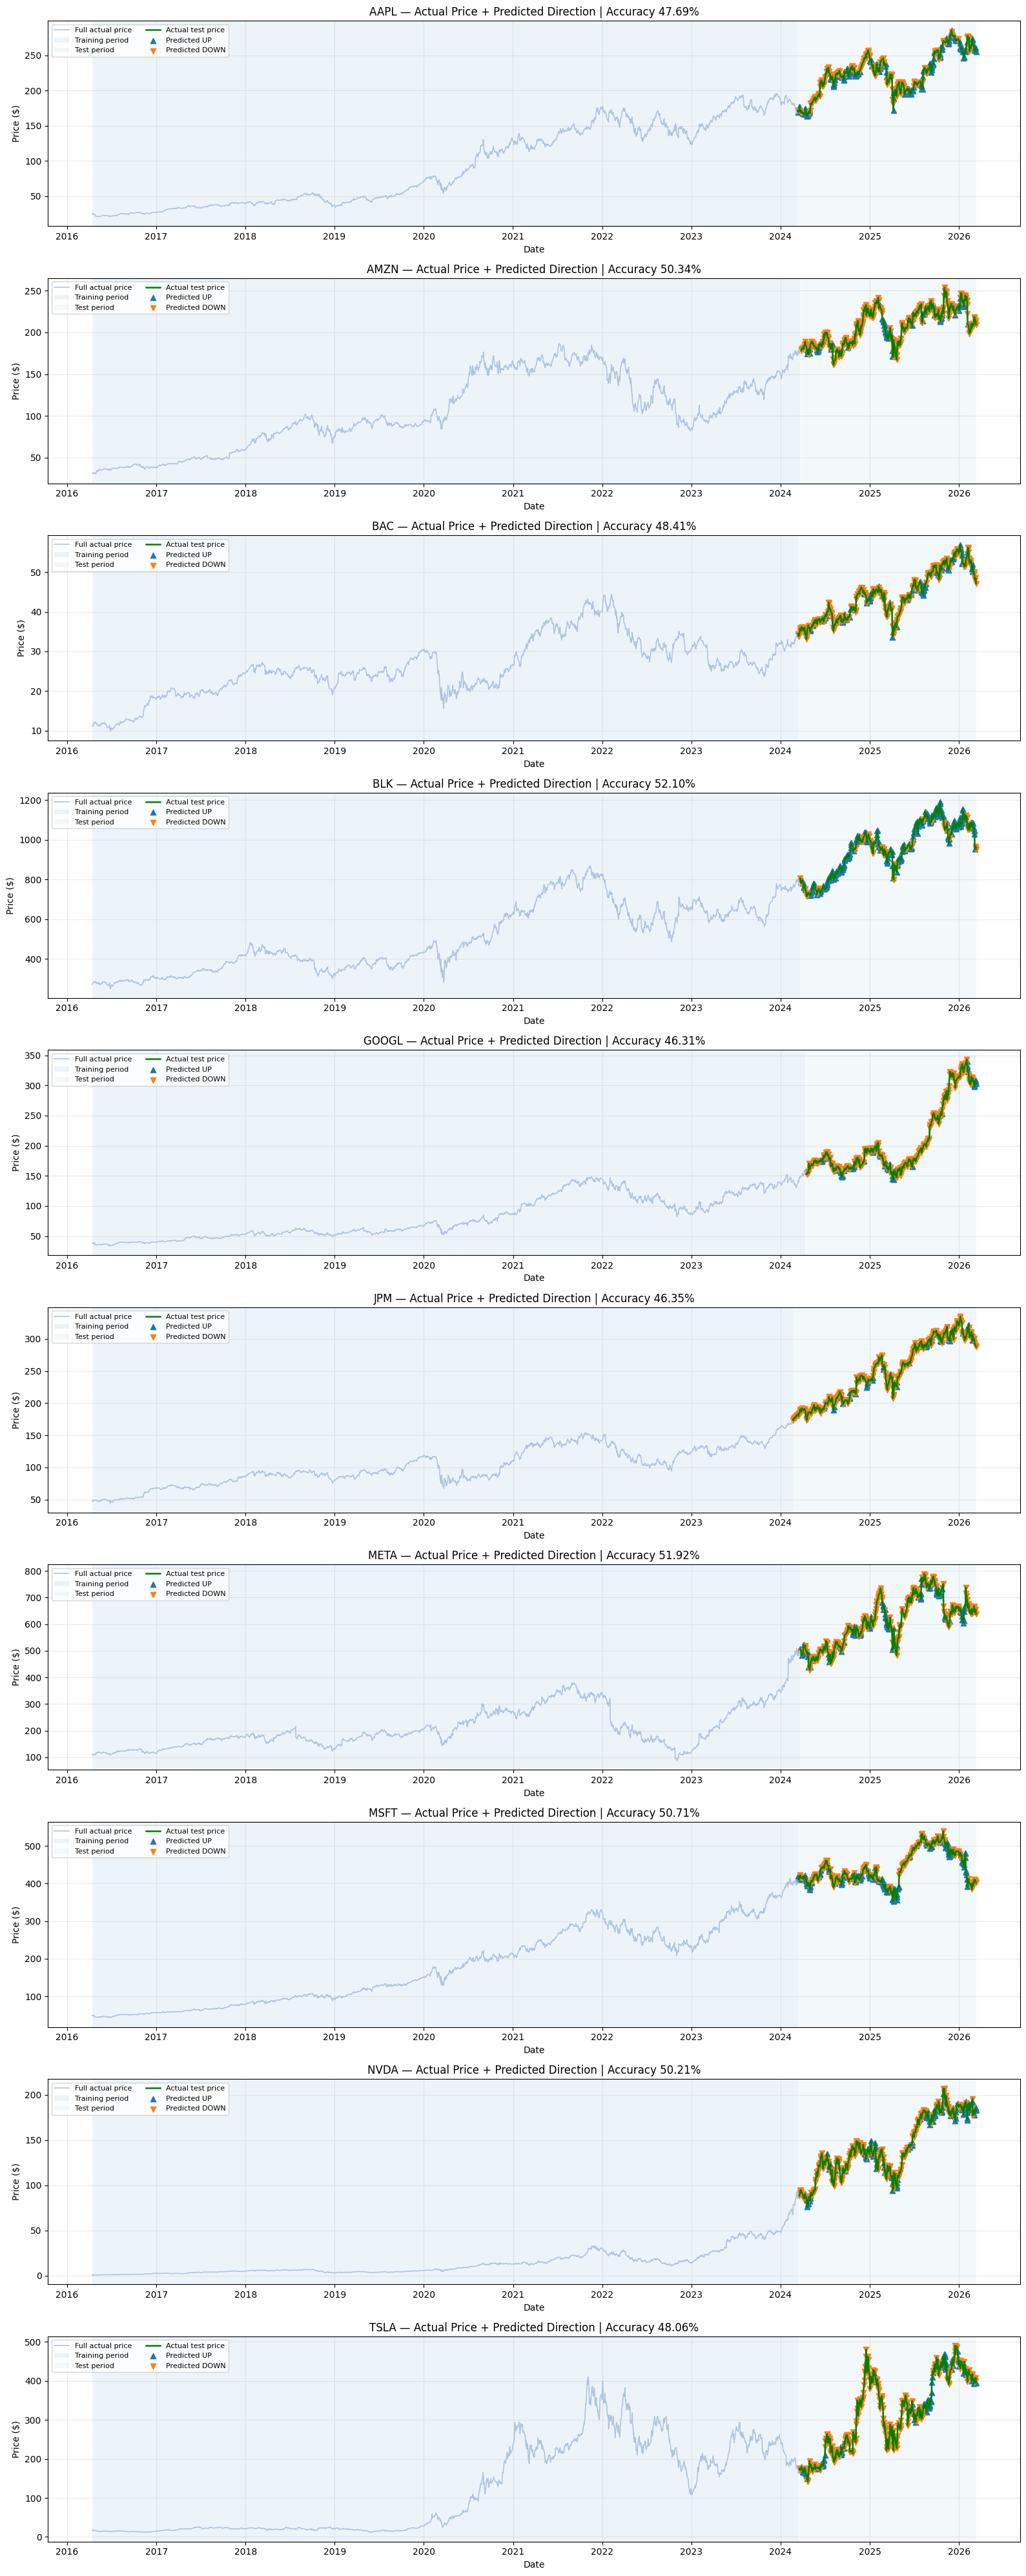

In [ ]:
# ============================================================
# GRAPH FOR EACH STOCK — ACTUAL PRICE + TRAIN/TEST + PREDICTED DIRECTION
# ============================================================

def plot_all_stock_direction_graphs(model, scalers, dfs, threshold=0.52):
    n_stocks = len(scalers)
    fig, axes = plt.subplots(n_stocks, 1, figsize=(16, 4 * n_stocks))

    if n_stocks == 1:
        axes = [axes]

    for ax, ticker in zip(axes, scalers.keys()):
        fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

        # Rebuild stock data
        X_tr, X_te, y_tr, y_te, scaler, df_feat = prepare_single_stock(fpath)

        # Model predictions
        y_pred_prob = model.predict(X_te, verbose=0).flatten()
        y_pred = (y_pred_prob >= threshold).astype(int)
        y_true = y_te.astype(int)

        # Full actual price
        price_series = df_feat['Close']

        # Train/test split for plotting
        train_end_idx = len(X_tr) + LOOKBACK
        test_start_idx = train_end_idx
        test_dates = df_feat.index[test_start_idx:test_start_idx + len(y_true)]
        test_prices = df_feat['Close'].iloc[test_start_idx:test_start_idx + len(y_true)]

        # Plot full actual price
        ax.plot(df_feat.index, price_series, color='lightsteelblue', linewidth=1.2, label='Full actual price')

        # Highlight train/test regions
        ax.axvspan(df_feat.index[0], df_feat.index[test_start_idx - 1], alpha=0.08, label='Training period')
        ax.axvspan(df_feat.index[test_start_idx], df_feat.index[-1], alpha=0.05, label='Test period')

        # Actual test price
        ax.plot(test_dates, test_prices, color='green', linewidth=1.8, label='Actual test price')

        # Predicted UP / DOWN markers on actual price
        up_mask = (y_pred == 1)
        down_mask = (y_pred == 0)

        ax.scatter(test_dates[up_mask], test_prices[up_mask],
                   marker='^', s=35, label='Predicted UP')
        ax.scatter(test_dates[down_mask], test_prices[down_mask],
                   marker='v', s=35, label='Predicted DOWN')

        acc = np.mean(y_pred == y_true) * 100

        ax.set_title(f'{ticker} — Actual Price + Predicted Direction | Accuracy {acc:.2f}%')
        ax.set_xlabel('Date')
        ax.set_ylabel('Price ($)')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()

plot_all_stock_direction_graphs(model, scalers, dfs, threshold=0.52)

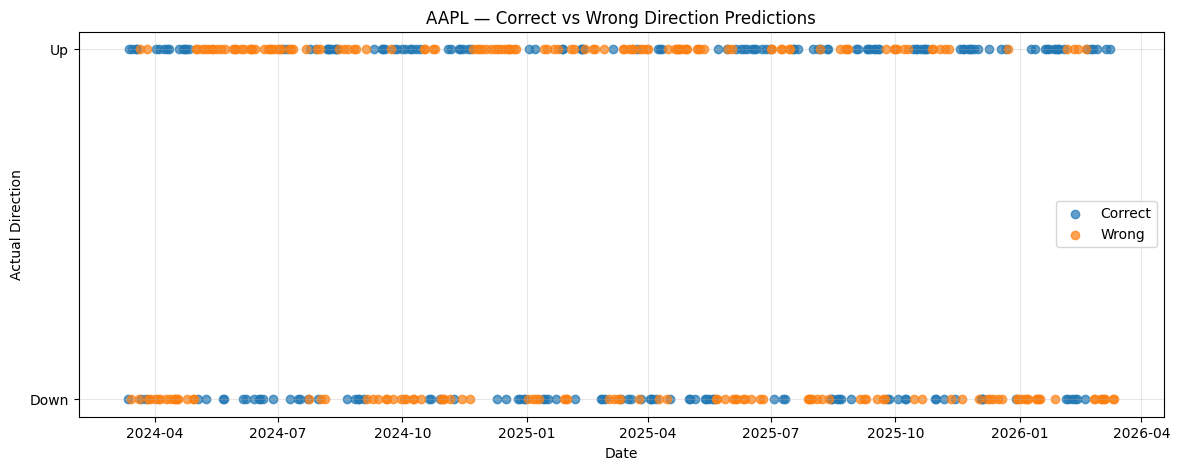

In [ ]:
# ============================================================
# CORRECT VS WRONG DIRECTION PREDICTIONS
# ============================================================

ticker = 'AAPL'
threshold = 0.52

fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])
_, X_te, _, y_te, _, df_feat = prepare_single_stock(fpath)

y_pred_prob = model.predict(X_te, verbose=0).flatten()
y_pred = (y_pred_prob >= threshold).astype(int)
y_true = y_te.astype(int)

test_dates = df_feat.index[-len(y_true):]
correct = (y_pred == y_true)

plt.figure(figsize=(14, 5))
plt.scatter(test_dates[correct], y_true[correct], label='Correct', alpha=0.7)
plt.scatter(test_dates[~correct], y_true[~correct], label='Wrong', alpha=0.7)
plt.title(f'{ticker} — Correct vs Wrong Direction Predictions')
plt.xlabel('Date')
plt.ylabel('Actual Direction')
plt.yticks([0, 1], ['Down', 'Up'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

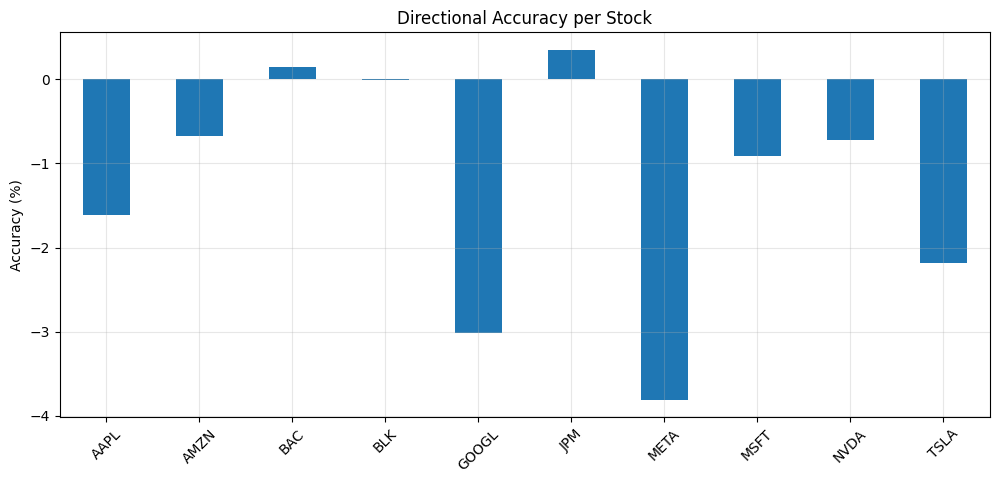

In [ ]:
# ============================================================
# BAR CHART — MODEL PERFORMANCE PER STOCK
# ============================================================

results_df = pd.DataFrame(results).T

results_df['Accuracy (%)'].plot(kind='bar', figsize=(12,5))
plt.title('Directional Accuracy per Stock')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def build_features_price(df):
    close  = df['Close']
    high   = df['High']
    low    = df['Low']
    volume = df['Volume']

    out = pd.DataFrame(index=df.index)

    # Base
    out['Close'] = close
    out['Log_Returns'] = np.log(close / close.shift(1))

    # Indicators
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    out['RSI_14'] = 100 - (100 / (1 + gain / loss))

    ema_9  = close.ewm(span=9,  adjust=False).mean()
    ema_20 = close.ewm(span=20, adjust=False).mean()
    out['EMA_ratio'] = ema_9 / ema_20

    out['Volume_ratio'] = volume / volume.rolling(20).mean()
    out['Volatility_20'] = out['Log_Returns'].rolling(20).std()

    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    macd   = ema_12 - ema_26
    signal = macd.ewm(span=9, adjust=False).mean()
    out['MACD_signal'] = (macd - signal) / close

    prev_close = close.shift(1)
    true_range = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    out['ATR_ratio'] = true_range.rolling(14).mean() / close

    out['Momentum_5'] = (close - close.shift(5)) / close.shift(5)

    # 🔥 TARGET (IMPORTANT)
    out['Target_Log_Return'] = np.log(close.shift(-1) / close)

    out.dropna(inplace=True)
    return out

In [ ]:
PRICE_FEATURE_COLS = [
    'Close',
    'Log_Returns',
    'RSI_14',
    'EMA_ratio',
    'Volume_ratio',
    'Volatility_20',
    'MACD_signal',
    'ATR_ratio',
    'Momentum_5',
]

def prepare_stock_price(file_path, lookback=LOOKBACK):

    df = pd.read_csv(file_path, index_col=0)
    df.index = pd.to_datetime(df.index)

    df = build_features_price(df)

    features = df[PRICE_FEATURE_COLS].values
    target   = df['Target_Log_Return'].values

    split = int(len(df) * TRAIN_RATIO)

    X_train_raw = features[:split]
    X_test_raw  = features[split:]

    y_train_raw = target[:split]
    y_test_raw  = target[split:]

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

    def create_sequences(X, y):
        X_seq, y_seq = [], []
        for i in range(lookback, len(X)):
            X_seq.append(X[i-lookback:i])
            y_seq.append(y[i])
        return np.array(X_seq), np.array(y_seq)

    X_train, y_train = create_sequences(X_train_scaled, y_train_raw)
    X_test,  y_test  = create_sequences(X_test_scaled,  y_test_raw)

    return X_train, X_test, y_train, y_test, scaler, df

In [ ]:
all_X_train, all_X_test = [], []
all_y_train, all_y_test = [], []

price_dfs = {}
price_scalers = {}   # ✅ ADD THIS

for ticker, filename in TICKERS.items():
    fpath = os.path.join(DRIVE_PATH, filename)

    X_tr, X_te, y_tr, y_te, scaler, df = prepare_stock_price(fpath)

    all_X_train.append(X_tr)
    all_X_test.append(X_te)
    all_y_train.append(y_tr)
    all_y_test.append(y_te)

    price_dfs[ticker] = df
    price_scalers[ticker] = scaler   # ✅ SAVE PER STOCK

X_train_p = np.concatenate(all_X_train)
X_test_p  = np.concatenate(all_X_test)
y_train_p = np.concatenate(all_y_train)
y_test_p  = np.concatenate(all_y_test)

print(X_train_p.shape, X_test_p.shape)

(19050, 90, 9) (4090, 90, 9)


In [ ]:
def build_price_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        Bidirectional(LSTM(32, return_sequences=True)),
        Dropout(0.2),

        GRU(32),
        Dropout(0.2),

        Dense(32, activation='relu'),
        Dense(1)  # 🔥 NO sigmoid
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0005),
        loss=tf.keras.losses.Huber()
    )

    return model

model_price = build_price_model((X_train_p.shape[1], X_train_p.shape[2]))

In [ ]:
history_p = model_price.fit(
    X_train_p, y_train_p,
    epochs=40,
    batch_size=32,
    validation_data=(X_test_p, y_test_p),
    verbose=1
)

Epoch 1/40
596/596 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - loss: 2.7312e-04 - val_loss: 2.5791e-04
Epoch 2/40
596/596 ━━━━━━━━━━━━━━━━━━━━ 81s 68ms/step - loss: 2.7315e-04 - val_loss: 2.5684e-04
Epoch 3/40
596/596 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - loss: 2.7309e-04 - val_loss: 2.5757e-04
Epoch 4/40
596/596 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - loss: 2.7214e-04 - val_loss: 2.5832e-04
Epoch 5/40
596/596 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - loss: 2.7166e-04 - val_loss: 2.5790e-04
Epoch 6/40
596/596 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - loss: 2.7121e-04 - val_loss: 2.5768e-04
Epoch 7/40
596/596 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - loss: 2.7132e-04 - val_loss: 2.5791e-04
Epoch 8/40
596/596 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - loss: 2.7133e-04 - val_loss: 2.5760e-04
Epoch 9/40
596/596 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - loss: 2.7202e-04 - val_loss: 2.5965e-04
Epoch 10/40
596/596 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - loss: 2.7174e-04 - val_loss: 2.5940e-04
Epoch 11/40
596/596 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# ============================================================
# SAVE PRICE MODEL + SCALER
# ============================================================

import os
import joblib

MODEL_PATH = "/content/drive/MyDrive/StockModels/"
os.makedirs(MODEL_PATH, exist_ok=True)

# Save model
model_price.save(os.path.join(MODEL_PATH, "price_model.keras"))

# Save scaler (single scaler used in price pipeline)
joblib.dump(price_scalers, os.path.join(MODEL_PATH, "price_scalers.pkl"))

print("✅ Price model + scaler saved!")

NameError: name 'price_scalers' is not defined

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
AAPL MAE: $2.76


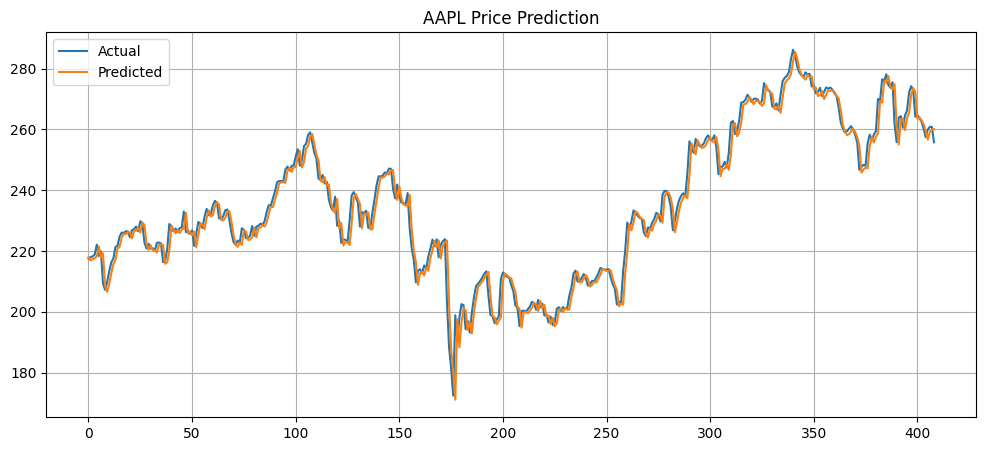

In [ ]:
from sklearn.metrics import mean_absolute_error

def evaluate_price_model(ticker):
    fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

    X_tr, X_te, y_tr, y_te, scaler, df = prepare_stock_price(fpath)

    pred_log = model_price.predict(X_te).flatten()

    actual_prices = []
    predicted_prices = []

    closes = df['Close'].values

    start = len(closes) - len(y_te)

    for i in range(len(y_te)):
        prev_close = closes[start + i - 1]

        actual = closes[start + i]
        pred   = prev_close * np.exp(pred_log[i])

        actual_prices.append(actual)
        predicted_prices.append(pred)

    mae = mean_absolute_error(actual_prices, predicted_prices)

    print(f"{ticker} MAE: ${mae:.2f}")

    plt.figure(figsize=(12,5))
    plt.plot(actual_prices, label='Actual')
    plt.plot(predicted_prices, label='Predicted')
    plt.title(f'{ticker} Price Prediction')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example
evaluate_price_model('AAPL')

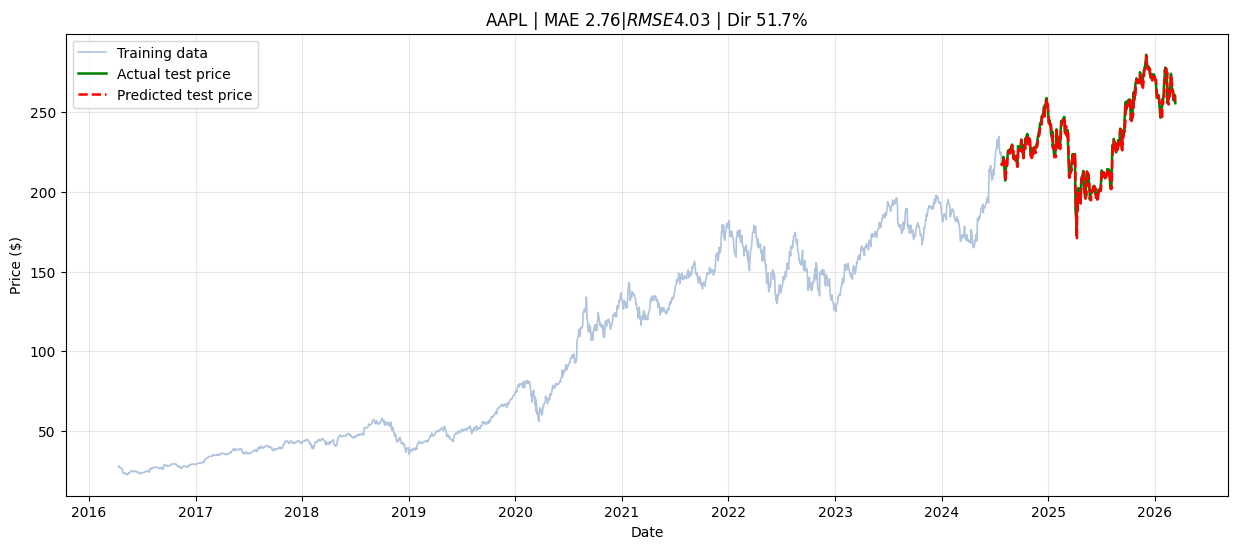

AAPL
MAE              : $2.76
RMSE             : $4.03
Direction Acc    : 51.72%


In [ ]:
# ============================================================
# SINGLE STOCK — FULL HISTORY + ACTUAL VS PREDICTED TEST PRICE
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

def plot_single_price_prediction(ticker, model_price):
    fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

    X_tr, X_te, y_tr, y_te, scaler, df = prepare_stock_price(fpath)

    # Predict next-day log returns
    pred_log = model_price.predict(X_te, verbose=0).flatten()

    actual_prices = []
    predicted_prices = []

    close_series = df['Close'].values
    dates = df.index

    split = int(len(df) * TRAIN_RATIO)
    test_start_idx = split + LOOKBACK

    for i in range(len(y_te)):
        current_idx = test_start_idx + i

        prev_close = close_series[current_idx - 1]
        actual_close = close_series[current_idx]
        predicted_close = prev_close * np.exp(pred_log[i])

        actual_prices.append(actual_close)
        predicted_prices.append(predicted_close)

    actual_prices = np.array(actual_prices)
    predicted_prices = np.array(predicted_prices)

    mae = mean_absolute_error(actual_prices, predicted_prices)
    rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

    actual_dir = np.sign(np.diff(actual_prices))
    pred_dir = np.sign(np.diff(predicted_prices))
    dir_acc = np.mean(actual_dir == pred_dir) * 100 if len(actual_dir) > 0 else np.nan

    test_dates = dates[test_start_idx:test_start_idx + len(actual_prices)]

    plt.figure(figsize=(15, 6))

    # Full training history
    plt.plot(
        dates[:test_start_idx],
        close_series[:test_start_idx],
        color='lightsteelblue',
        linewidth=1.2,
        label='Training data'
    )

    # Actual and predicted test prices
    plt.plot(
        test_dates,
        actual_prices,
        color='green',
        linewidth=1.8,
        label='Actual test price'
    )

    plt.plot(
        test_dates,
        predicted_prices,
        color='red',
        linestyle='--',
        linewidth=1.8,
        label='Predicted test price'
    )

    plt.fill_between(
        test_dates,
        actual_prices,
        predicted_prices,
        color='red',
        alpha=0.08
    )

    plt.title(f'{ticker} | MAE ${mae:.2f} | RMSE ${rmse:.2f} | Dir {dir_acc:.1f}%')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"{ticker}")
    print(f"MAE              : ${mae:.2f}")
    print(f"RMSE             : ${rmse:.2f}")
    print(f"Direction Acc    : {dir_acc:.2f}%")

# Example
plot_single_price_prediction('AAPL', model_price)

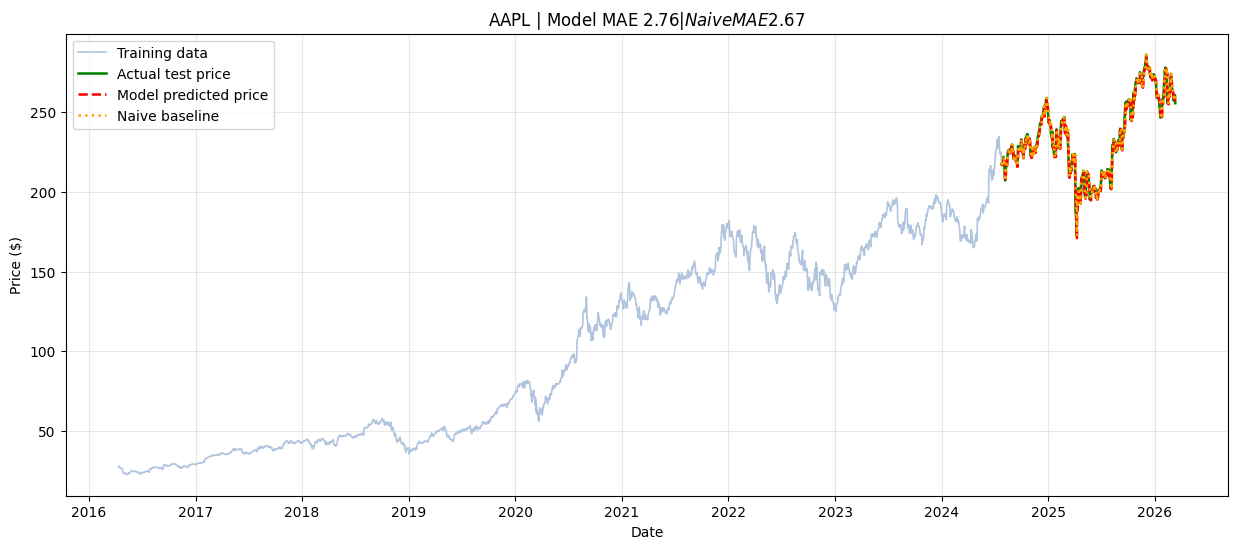

AAPL
Model MAE   : $2.76
Model RMSE  : $4.03
Naive MAE   : $2.67
Naive RMSE  : $3.96


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_single_price_prediction_with_baseline(ticker, model_price):
    fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

    X_tr, X_te, y_tr, y_te, scaler, df = prepare_stock_price(fpath)

    pred_log = model_price.predict(X_te, verbose=0).flatten()

    actual_prices = []
    predicted_prices = []
    naive_prices = []

    close_series = df['Close'].values
    dates = df.index

    split = int(len(df) * TRAIN_RATIO)
    test_start_idx = split + LOOKBACK

    for i in range(len(y_te)):
        current_idx = test_start_idx + i

        prev_close = close_series[current_idx - 1]
        actual_close = close_series[current_idx]
        predicted_close = prev_close * np.exp(pred_log[i])

        actual_prices.append(actual_close)
        predicted_prices.append(predicted_close)
        naive_prices.append(prev_close)

    actual_prices = np.array(actual_prices)
    predicted_prices = np.array(predicted_prices)
    naive_prices = np.array(naive_prices)

    mae_model = mean_absolute_error(actual_prices, predicted_prices)
    rmse_model = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

    mae_naive = mean_absolute_error(actual_prices, naive_prices)
    rmse_naive = np.sqrt(mean_squared_error(actual_prices, naive_prices))

    test_dates = dates[test_start_idx:test_start_idx + len(actual_prices)]

    plt.figure(figsize=(15, 6))

    plt.plot(
        dates[:test_start_idx],
        close_series[:test_start_idx],
        color='lightsteelblue',
        linewidth=1.2,
        label='Training data'
    )

    plt.plot(
        test_dates,
        actual_prices,
        color='green',
        linewidth=1.8,
        label='Actual test price'
    )

    plt.plot(
        test_dates,
        predicted_prices,
        color='red',
        linestyle='--',
        linewidth=1.8,
        label='Model predicted price'
    )

    plt.plot(
        test_dates,
        naive_prices,
        color='orange',
        linestyle=':',
        linewidth=1.8,
        label='Naive baseline'
    )

    plt.title(
        f"{ticker} | Model MAE ${mae_model:.2f} | Naive MAE ${mae_naive:.2f}"
    )
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"{ticker}")
    print(f"Model MAE   : ${mae_model:.2f}")
    print(f"Model RMSE  : ${rmse_model:.2f}")
    print(f"Naive MAE   : ${mae_naive:.2f}")
    print(f"Naive RMSE  : ${rmse_naive:.2f}")

plot_single_price_prediction_with_baseline('AAPL', model_price)

2-WEEK PRICE FORECAST — AAPL
        Date  Predicted_Close  Predicted_Log_Return
0 2026-03-16       254.996734             -0.002989
1 2026-03-17       249.363473             -0.003029
2 2026-03-18       254.251117             -0.002928
3 2026-03-19       248.585190             -0.003126
4 2026-03-20       253.473446             -0.003063
5 2026-03-23       247.792875             -0.003192
6 2026-03-24       252.721496             -0.002971
7 2026-03-25       247.038133             -0.003051
8 2026-03-26       252.003244             -0.002846
9 2026-03-27       246.311414             -0.002946


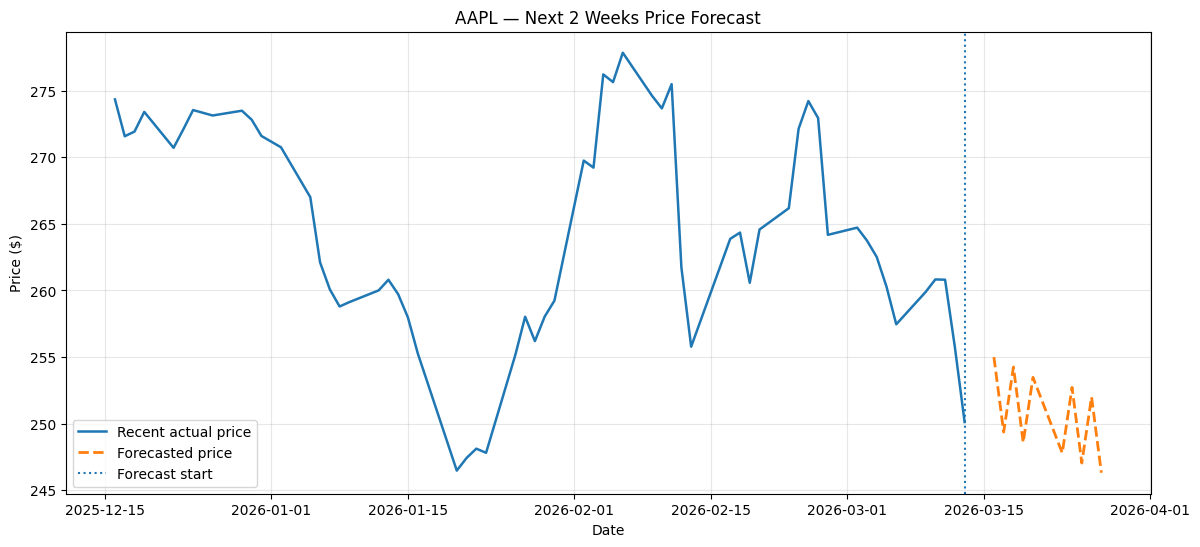

2-WEEK PRICE FORECAST — GOOGL
        Date  Predicted_Close  Predicted_Log_Return
0 2026-03-16       302.176513             -0.004535
1 2026-03-17       300.941314             -0.004438
2 2026-03-18       300.830812             -0.004463
3 2026-03-19       299.570979             -0.004564
4 2026-03-20       299.435195             -0.004650
5 2026-03-23       298.170154             -0.004687
6 2026-03-24       298.040252             -0.004669
7 2026-03-25       296.777052             -0.004683
8 2026-03-26       296.652963             -0.004666
9 2026-03-27       295.390972             -0.004681


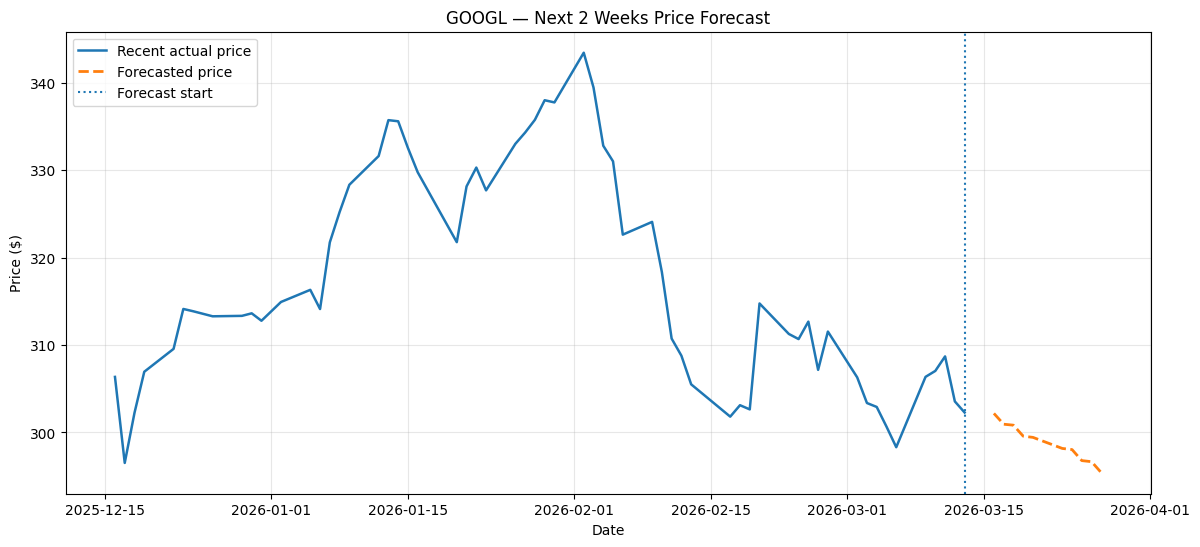

In [ ]:
# ============================================================
# 2-WEEK PRICE FORECAST + GRAPH
# ============================================================

def forecast_next_2_weeks_price(ticker, model_price, forecast_days=10):
    fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

    # Load raw stock file
    df_raw = pd.read_csv(fpath, index_col=0)
    df_raw.index = pd.to_datetime(df_raw.index)

    # Build initial feature dataframe
    df_feat = build_features_price(df_raw).copy()

    # Prepare scaler using same stock pipeline
    X_tr, X_te, y_tr, y_te, scaler, df_prepared = prepare_stock_price(fpath)

    forecasts = []
    working_df = df_raw.copy()

    last_date = working_df.index[-1]

    for step in range(forecast_days):
        # Rebuild features from updated raw dataframe
        feat_df = build_features_price(working_df).copy()

        # Need the latest lookback rows of features
        latest_features = feat_df[PRICE_FEATURE_COLS].tail(LOOKBACK).values

        if len(latest_features) < LOOKBACK:
            print(f"Not enough rows to forecast {ticker}")
            return None

        latest_scaled = scaler.transform(latest_features)
        X_input = latest_scaled.reshape(1, LOOKBACK, len(PRICE_FEATURE_COLS))

        # Predict next-day log return
        pred_log = model_price.predict(X_input, verbose=0)[0, 0]

        # Last known close
        prev_close = feat_df['Close'].iloc[-1]
        predicted_close = prev_close * np.exp(pred_log)

        # Find next trading day
        next_date = last_date + pd.Timedelta(days=1)
        while next_date.weekday() >= 5:
            next_date += pd.Timedelta(days=1)

        # Create a synthetic next row
        new_row = working_df.iloc[-1].copy()

        # If raw file has Adj Close, keep it aligned with Close
        close_col = 'Adj Close' if 'Adj Close' in working_df.columns else 'Close'

        new_row['Open'] = prev_close
        new_row['High'] = max(prev_close, predicted_close)
        new_row['Low'] = min(prev_close, predicted_close)
        new_row['Close'] = predicted_close
        new_row[close_col] = predicted_close
        new_row['Volume'] = working_df['Volume'].iloc[-1]  # carry forward last volume

        # Append future row
        working_df.loc[next_date] = new_row

        forecasts.append({
            'Date': next_date,
            'Predicted_Close': predicted_close,
            'Predicted_Log_Return': pred_log
        })

        last_date = next_date

    forecast_df = pd.DataFrame(forecasts)

    print("=" * 60)
    print(f"2-WEEK PRICE FORECAST — {ticker}")
    print("=" * 60)
    print(forecast_df)

    # Plot recent actual + forecast
    plt.figure(figsize=(14, 6))

    recent_close_col = 'Adj Close' if 'Adj Close' in df_raw.columns else 'Close'
    recent_actual = df_raw[[recent_close_col]].tail(60).copy()

    plt.plot(
        recent_actual.index,
        recent_actual[recent_close_col],
        label='Recent actual price',
        linewidth=1.8
    )

    plt.plot(
        forecast_df['Date'],
        forecast_df['Predicted_Close'],
        linestyle='--',
        linewidth=2,
        label='Forecasted price'
    )

    plt.axvline(recent_actual.index[-1], linestyle=':', linewidth=1.5, label='Forecast start')

    plt.title(f'{ticker} — Next 2 Weeks Price Forecast')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return forecast_df

# Example
forecast_2weeks_df = forecast_next_2_weeks_price('AAPL', model_price, forecast_days=10)
forecast_2weeks_df = forecast_next_2_weeks_price('GOOGL', model_price, forecast_days=10)

In [ ]:
# ============================================================
# CELL 9 — 2-WEEK FORECAST
#
# Change FORECAST_TICKER to any of the 10 loaded stocks.
# Available: AAPL  AMZN  BAC  BLK  GOOGL
#            JPM   META  MSFT NVDA  TSLA
#
# Note on reliability:
# Day 1–3 predictions are most reliable. By day 10 the
# uncertainty band is wide because each prediction builds
# on the previous one's error. Use as a directional guide,
# not precise price targets.
# ============================================================

FORECAST_TICKER = 'AAPL'

def predict_two_weeks(ticker, model, scalers, days=10):
    if ticker not in scalers:
        print(f"'{ticker}' not found.")
        print(f"Available: {list(scalers.keys())}")
        return

    scaler    = scalers[ticker]
    file_path = os.path.join(DRIVE_PATH, TICKERS[ticker])

    df_raw = pd.read_csv(file_path, index_col=0)
    df_raw.index = pd.to_datetime(df_raw.index)
    df_feat = build_features(df_raw)

    last_date  = df_feat.index[-1]
    last_close = df_feat['Close'].iloc[-1]

    # Seed the window with the last 60 known days
    window = scaler.transform(
        df_feat[FEATURE_COLS].tail(LOOKBACK).values
    ).reshape(1, LOOKBACK, len(FEATURE_COLS))

    future_scaled = []

    for _ in range(days):
        pred = model.predict(window, verbose=0)[0, 0]
        future_scaled.append(pred)

        # Slide window: update Close (col 0),
        # keep other features from last known day
        next_row    = window[0, -1, :].copy()
        next_row[0] = pred
        window = np.append(
            window[:, 1:, :],
            next_row.reshape(1, 1, -1),
            axis=1
        )

    # Inverse-transform all predictions at once
    dummy        = np.zeros((days, scaler.n_features_in_))
    dummy[:, 0]  = future_scaled
    predicted_prices = scaler.inverse_transform(dummy)[:, 0]

    # Generate future trading dates (skip weekends)
    future_dates = []
    current      = last_date
    while len(future_dates) < days:
        current += timedelta(days=1)
        if current.weekday() < 5:
            future_dates.append(current)

    # Print forecast table
    print("=" * 50)
    print(f"  2-WEEK FORECAST — {ticker}")
    print("=" * 50)
    print(f"  Last close "
          f"({last_date.strftime('%Y-%m-%d')}) : ${last_close:.2f}")
    print("-" * 50)
    print(f"  {'Date':<14} {'Predicted':>10} "
          f"{'Change':>10}  {'Dir':>4}")
    print("-" * 50)

    prev = last_close
    for date, price in zip(future_dates, predicted_prices):
        change    = price - prev
        direction = "▲" if change >= 0 else "▼"
        print(f"  {date.strftime('%Y-%m-%d'):<14} "
              f"${price:>8.2f}  "
              f"{direction} ${abs(change):>6.2f}")
        prev = price

    print("-" * 50)
    total   = predicted_prices[-1] - last_close
    outlook = "UP" if total >= 0 else "DOWN"
    print(f"  2-week outlook : {outlook}  ${abs(total):.2f} total")
    print("=" * 50)

    # Chart — last 60 days actual + 10-day forecast
    history_dates  = df_feat.index[-60:]
    history_prices = df_feat['Close'].iloc[-60:].values
    uncertainty    = np.array([
        i * 0.003 * predicted_prices[i] for i in range(days)
    ])

    plt.figure(figsize=(14, 6))
    plt.title(
        f'{ticker} — 2-week price forecast (BiLSTM + GRU)',
        fontsize=14
    )
    plt.plot(history_dates, history_prices,
             label='Recent actual price',
             color='steelblue', linewidth=1.8)
    plt.plot(future_dates, predicted_prices,
             label='Forecast', color='red',
             linestyle='dashed', linewidth=1.8,
             marker='o', markersize=4)
    plt.fill_between(
        future_dates,
        predicted_prices - uncertainty,
        predicted_prices + uncertainty,
        alpha=0.15, color='red',
        label='Uncertainty band'
    )
    plt.axvline(
        x=last_date, color='gray',
        linestyle=':', linewidth=1.2,
        label='Forecast start'
    )
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    return predicted_prices, future_dates


predict_two_weeks(FORECAST_TICKER, model, scalers)

In [ ]:
# ============================================================
# CELL 10 — SINGLE STOCK DEEP DIVE
# Full analysis for one stock at a time:
#   - Predicted vs Actual chart (full test period)
#   - Performance metrics
#   - Next-day prediction
#   - 2-week forecast chart
#
# Change STOCK to any of the 10 loaded tickers:
# AAPL  AMZN  BAC  BLK  GOOGL  JPM  META  MSFT  NVDA  TSLA
# ============================================================

STOCK = 'TSLA'   # ← change this to any ticker

# ── helper: inverse-transform scaled Close values ─────────
def rescale_close(vals, scaler):
    dummy       = np.zeros((len(vals), scaler.n_features_in_))
    dummy[:, 0] = vals
    return scaler.inverse_transform(dummy)[:, 0]


def single_stock_analysis(ticker, model, scalers, dfs):
    if ticker not in scalers:
        print(f"'{ticker}' not found.")
        print(f"Available: {list(scalers.keys())}")
        return

    scaler    = scalers[ticker]
    df        = dfs[ticker]
    file_path = os.path.join(DRIVE_PATH, TICKERS[ticker])

    # ── 1. Rebuild test sequences for this stock ──────────
    _, X_te, _, y_te, _, _ = prepare_single_stock(file_path)

    y_pred_scaled = model.predict(X_te, verbose=0).flatten()
    y_pred        = rescale_close(y_pred_scaled, scaler)
    y_true        = rescale_close(y_te, scaler)

    # ── 2. Metrics ────────────────────────────────────────
    mae     = mean_absolute_error(y_true, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mape    = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    dir_acc = np.mean(
        np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))
    ) * 100

    print("=" * 48)
    print(f"  DEEP DIVE — {ticker}")
    print("=" * 48)
    print(f"  MAE              : ${mae:.2f}")
    print(f"  RMSE             : ${rmse:.2f}")
    print(f"  Price accuracy   : {100 - mape:.2f}%")
    print(f"  Direction acc    : {dir_acc:.2f}%")
    print("=" * 48)

    # ── 3. Predicted vs Actual chart ──────────────────────
    test_dates = df.index[-len(y_true):]

    fig, axes = plt.subplots(2, 1, figsize=(16, 12))

    # Top chart — full history + test period
    ax1 = axes[0]
    ax1.plot(
        df.index[:-len(y_true)],
        df['Close'].iloc[:-len(y_true)],
        color='steelblue', alpha=0.3,
        linewidth=1, label='Training data'
    )
    ax1.plot(
        test_dates, y_true,
        color='green', linewidth=1.6,
        label='Actual price (test period)'
    )
    ax1.plot(
        test_dates, y_pred,
        color='red', linewidth=1.6,
        linestyle='dashed', label='Predicted price'
    )
    ax1.fill_between(
        test_dates, y_true, y_pred,
        alpha=0.1, color='red', label='Error band'
    )
    ax1.set_title(
        f"{ticker} — Predicted vs Actual  |  "
        f"MAE ${mae:.2f}  |  Dir Acc {dir_acc:.1f}%",
        fontsize=13, fontweight='bold'
    )
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price ($)')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.2)

    # Bottom chart — zoom into test period only
    ax2 = axes[1]
    ax2.plot(
        test_dates, y_true,
        color='green', linewidth=1.6,
        label='Actual price'
    )
    ax2.plot(
        test_dates, y_pred,
        color='red', linewidth=1.6,
        linestyle='dashed', label='Predicted price'
    )
    ax2.fill_between(
        test_dates, y_true, y_pred,
        alpha=0.12, color='red'
    )
    ax2.set_title(
        f"{ticker} — Test period zoomed in",
        fontsize=12, fontweight='bold'
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Price ($)')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    # ── 4. Next-day prediction ────────────────────────────
    df_raw = pd.read_csv(file_path, index_col=0)
    df_raw.index = pd.to_datetime(df_raw.index)
    df_feat = build_features(df_raw)

    recent = df_feat[FEATURE_COLS].tail(LOOKBACK).values
    scaled = scaler.transform(recent).reshape(
        1, LOOKBACK, len(FEATURE_COLS)
    )

    pred_scaled = model.predict(scaled, verbose=0)[0, 0]
    next_price  = rescale_close(
        np.array([pred_scaled]), scaler
    )[0]

    last_close = df_feat['Close'].iloc[-1]
    last_date  = df_feat.index[-1]
    change     = next_price - last_close
    direction  = "UP" if change > 0 else "DOWN"

    next_date = last_date + timedelta(days=1)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    print(f"\n  NEXT-DAY PREDICTION — {ticker}")
    print("-" * 48)
    print(f"  Data up to  :  {last_date.strftime('%Y-%m-%d')}")
    print(f"  Predicting  :  {next_date.strftime('%Y-%m-%d')}")
    print(f"  Last close  :  ${last_close:.2f}")
    print(f"  Predicted   :  ${next_price:.2f}")
    print(f"  Direction   :  {direction}  ${abs(change):.2f}")
    print("-" * 48)

    # ── 5. 2-week forecast ────────────────────────────────
    days   = 10
    window = scaler.transform(
        df_feat[FEATURE_COLS].tail(LOOKBACK).values
    ).reshape(1, LOOKBACK, len(FEATURE_COLS))

    future_scaled = []
    for _ in range(days):
        pred        = model.predict(window, verbose=0)[0, 0]
        future_scaled.append(pred)
        next_row    = window[0, -1, :].copy()
        next_row[0] = pred
        window = np.append(
            window[:, 1:, :],
            next_row.reshape(1, 1, -1),
            axis=1
        )

    dummy        = np.zeros((days, scaler.n_features_in_))
    dummy[:, 0]  = future_scaled
    forecast     = scaler.inverse_transform(dummy)[:, 0]

    future_dates = []
    current      = last_date
    while len(future_dates) < days:
        current += timedelta(days=1)
        if current.weekday() < 5:
            future_dates.append(current)

    # Print forecast table
    print(f"\n  2-WEEK FORECAST — {ticker}")
    print("-" * 48)
    print(f"  {'Date':<14} {'Predicted':>10} "
          f"{'Change':>10}  {'Dir':>4}")
    print("-" * 48)

    prev = last_close
    for date, price in zip(future_dates, forecast):
        change    = price - prev
        direction = "▲" if change >= 0 else "▼"
        print(f"  {date.strftime('%Y-%m-%d'):<14} "
              f"${price:>8.2f}  "
              f"{direction} ${abs(change):>6.2f}")
        prev = price

    total   = forecast[-1] - last_close
    outlook = "UP" if total >= 0 else "DOWN"
    print("-" * 48)
    print(f"  2-week outlook : {outlook}  ${abs(total):.2f} total")
    print("=" * 48)

    # Forecast chart
    history_dates  = df_feat.index[-60:]
    history_prices = df_feat['Close'].iloc[-60:].values
    uncertainty    = np.array([
        i * 0.003 * forecast[i] for i in range(days)
    ])

    plt.figure(figsize=(14, 6))
    plt.title(
        f'{ticker} — 2-week price forecast',
        fontsize=14, fontweight='bold'
    )
    plt.plot(
        history_dates, history_prices,
        label='Recent actual price',
        color='steelblue', linewidth=1.8
    )
    plt.plot(
        future_dates, forecast,
        label='Forecast', color='red',
        linestyle='dashed', linewidth=1.8,
        marker='o', markersize=5
    )
    plt.fill_between(
        future_dates,
        forecast - uncertainty,
        forecast + uncertainty,
        alpha=0.15, color='red',
        label='Uncertainty band'
    )
    plt.axvline(
        x=last_date, color='gray',
        linestyle=':', linewidth=1.2,
        label='Forecast start'
    )
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


# ── Run it ────────────────────────────────────────────────
single_stock_analysis(STOCK, model, scalers, dfs)

In [ ]:
# Run this immediately to save your work
import pickle, os

MODEL_FILE   = os.path.join(DRIVE_PATH, 'multi_stock_BiLSTM_GRU.keras')
SCALERS_FILE = os.path.join(DRIVE_PATH, 'multi_stock_scalers.pkl')

model.save(MODEL_FILE)
with open(SCALERS_FILE, 'wb') as f:
    pickle.dump(scalers, f)

print(f"✅ Model saved   → {MODEL_FILE}")
print(f"✅ Scalers saved → {SCALERS_FILE}")